We are going to run the same model but this time we are going to use the package xarray to handle all the backend again going forward

In [430]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

This time, we’re going to start by defining the workflow of the model rather than beginning with the data. Doing so allows us to lay out the steps logically, focusing solely on constructing a sound methodology independent of any specific dataset.

This approach also aligns with good scientific practice. A core principle in science is maintaining a clear separation between methodology and data. If you build your model while simultaneously looking at the data, it becomes very easy to fall into _HARKing_ (hypothesising after results are known). When results don’t match your expectations, there’s a natural temptation to 'fix' the model on the spot, smoothing over inconsistencies without fully considering their implications across the entire system.
By defining the full workflow before introducing any data, we avoid these risks. It helps ensure that unexpected outcomes are treated as informative signals rather than mistakes to quietly correct. In short laying out the complete model first encourtages transparency and robustness.

Lets define a model

In [431]:
def calc_carbon_cost(year):
    cost = 10 + ((year-2026)**0.6)
    return cost

In [432]:
def calc_emissions(ds):
    ds['emissions_tons_per_year'] = ds['emissions_tons_per_kwh'] * ds['power_kwh']
    return ds

In [433]:
def calc_offset_cost(ds):
    ds['offset_cost_gbp_per_year'] = ds['offset_base_cost_gbp_per_ton'] * ds['emissions_tons_per_year']
    return ds

it can be tricky to remember what goes into each function exactly. If you add a `docstring` to the strat of a function, it can be picked up by the python interpreter and prompt you how to use the function

_docstrings run deep. there are many types of formatting. This is a numpy style doc string and is widely recognised by interpreters. The style guide is here https://numpydoc.readthedocs.io/en/latest/format.html_

In [434]:
def plot_element_over_time(ds, dim, key, label):
    """
    Plot a stacked area chart of a dataset aggregated over a dimension.

    Parameters:
        ds : xarray.Dataset
            Dataset
        dim : str or list[str]
            Dimension(s) to sum over before plotting.
        key : str
            Name of the data variable to extract after summing. Can't be in summing list!
        label : str
            Coordinate used to label each stacked area segment. Cant be in summing list!

    Displays a matplotlib stackplot of the aggregated values over time.
    """


    ds_y = ds.sum(dim=dim)[key]
    plt.stackplot(ds_y['year'],
                ds_y.values.T,
                labels=ds_y[label].values
                )
    plt.legend()

## Data Loading

only now will we will read some data from a  spreadsheet as before

In [435]:
vehicles = pd.read_csv(r"data\vehicles.csv")
power_kwh = (vehicles
            .set_index(["vehicle", "fuel"])
            .to_xarray())  # power_kwh becomes a data variable
power_kwh

<xarray.Dataset> Size: 88B
Dimensions:    (vehicle: 3, fuel: 2)
Coordinates:
  * vehicle    (vehicle) object 24B 'generator' 'lawnmower' 'tractor'
  * fuel       (fuel) object 16B 'diesel' 'petrol'
Data variables:
    power_kwh  (vehicle, fuel) float64 48B 2.3e+03 1.1e+03 nan 450.0 9e+03 nan

ok lets import fuel

In [436]:
fuel = pd.read_csv(r"data\fuel.csv")
emissions_tons_per_kwh = (fuel
                .set_index("fuel")["emissions_tons_per_kwh"]
                .to_xarray())
emissions_tons_per_kwh

<xarray.DataArray 'emissions_tons_per_kwh' (fuel: 2)> Size: 16B
array([0.25, 0.35])
Coordinates:
  * fuel     (fuel) object 16B 'petrol' 'diesel'

setting up the model window is still the same, but now we are loading the definition that we made earlier rather than making a new one here

In [437]:
years = np.arange(2026,2030,1)

offset_base_cost_gbp_per_ton = calc_carbon_cost(years)

offset_base_cost_gbp_per_ton = xr.DataArray(
    offset_base_cost_gbp_per_ton,
    coords={"year": years},
    dims=("year",),
    name="offset_base_cost_gbp_per_ton",
)
offset_base_cost_gbp_per_ton


<xarray.DataArray 'offset_base_cost_gbp_per_ton' (year: 4)> Size: 32B
array([10.        , 11.        , 11.51571657, 11.93318204])
Coordinates:
  * year     (year) int64 32B 2026 2027 2028 2029

now we merge the data into the expected dataframe

In [438]:
ds = power_kwh.merge(offset_base_cost_gbp_per_ton)
ds['emissions_tons_per_kwh'] = emissions_tons_per_kwh

ds

<xarray.Dataset> Size: 168B
Dimensions:                       (vehicle: 3, fuel: 2, year: 4)
Coordinates:
  * vehicle                       (vehicle) object 24B 'generator' ... 'tractor'
  * fuel                          (fuel) object 16B 'diesel' 'petrol'
  * year                          (year) int64 32B 2026 2027 2028 2029
Data variables:
    power_kwh                     (vehicle, fuel) float64 48B 2.3e+03 ... nan
    offset_base_cost_gbp_per_ton  (year) float64 32B 10.0 11.0 11.52 11.93
    emissions_tons_per_kwh        (fuel) float64 16B 0.35 0.25

now we can do the experiment as we set out above

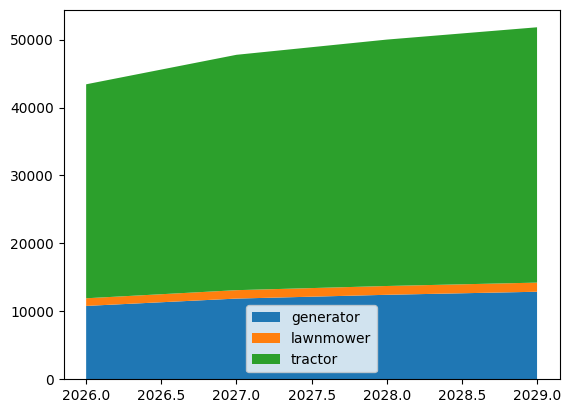

In [439]:
ds = calc_emissions(ds)
ds = calc_offset_cost(ds)

plot_element_over_time(
    ds,
    'fuel',
    'offset_cost_gbp_per_year',
    'vehicle'
)

this way if we want to change something about the experiment, such as say to minimise impact to already relatively low emissions vehicles, there is a a 95% discount on the first 100 tons of emmision per archetype/fuel pair 

this is as simple as changing the relevant function

In [440]:

def calc_offset_cost(ds):
    # first 100 tons
    discounted_tons = np.minimum(ds['emissions_tons_per_year'], 100)
    # overflow
    full_price_tons = np.maximum(ds['emissions_tons_per_year'] - 100, 0)

    ds['offset_cost_gbp_per_year'] = ds['offset_base_cost_gbp_per_ton'] * (0.05 * discounted_tons + full_price_tons)
    return ds


and rerunning the experiment

we have to make a deep copy of the database to make sure that we store our results in a different place to the original results. Otherwise we will just overwrite them

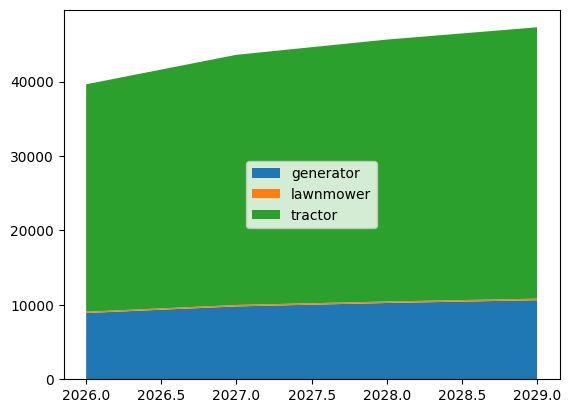

In [441]:
ds_discount = calc_emissions(ds.copy(deep=True))
ds_discount = calc_offset_cost(ds_discount)

plot_element_over_time(
    ds_discount,
    'fuel',
    'offset_cost_gbp_per_year',
    'vehicle'
)

now if we want to compare the two experiments we can just calculate the residuals

In [442]:
frac_residual = (ds_discount['offset_cost_gbp_per_year'] - ds['offset_cost_gbp_per_year']) / ds['offset_cost_gbp_per_year']

# aggregate over time
all_time = frac_residual.mean(dim='year') * -100  # percentage

# stack to one dimension (pair = vehicle,fuel)
fuel_vehicle_pairs = all_time.stack(pair=('vehicle', 'fuel'))

fuel_vehicle_pairs

<xarray.DataArray 'offset_cost_gbp_per_year' (pair: 6)> Size: 48B
array([11.80124224, 34.54545455,         nan, 84.44444444,  3.01587302,
               nan])
Coordinates:
  * pair     (pair) object 48B MultiIndex
  * vehicle  (pair) object 48B 'generator' 'generator' ... 'tractor' 'tractor'
  * fuel     (pair) object 48B 'diesel' 'petrol' 'diesel' ... 'diesel' 'petrol'

and plot the yearly cost reduction for each vehicle fuel pair as a percentage.

 (this is technically the yearly average, but as there is no yearly component to calc offset cost then there this is also just the actual yearly percentage cost as percentage cost does not vary with time)

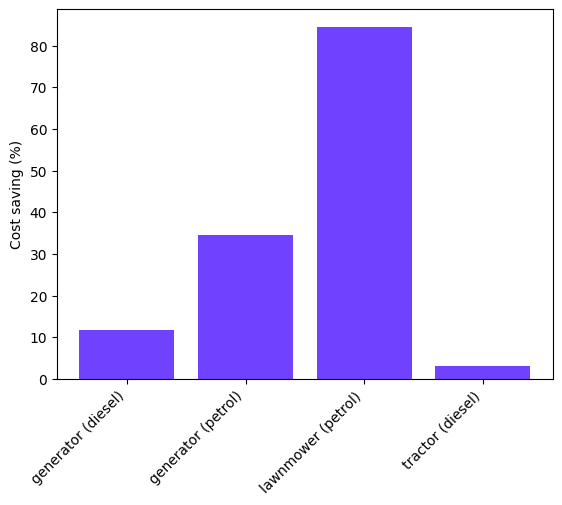

In [443]:
# drop pairs which dont exist aka petrol tractors etc
agg_stacked = fuel_vehicle_pairs[np.isfinite(fuel_vehicle_pairs.values)]

# make readable strings for plot labels
x_labels = [f"{v} ({f})" for (v, f) in agg_stacked['pair'].values]

plt.bar(x_labels, agg_stacked.values, color = "#7041FF")
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cost saving (%)')
plt.show()